# Step 1: Data Loading and Initial Inspection

In this step, we load the Heart Disease dataset and perform an initial inspection.
The goal is to understand the structure of the data, the available features,
the target variable, and identify potential issues such as missing values
or inconsistent data types.

This step is critical because any mistake or assumption at the data level
will propagate through the entire machine learning pipeline.


In [2]:
import numpy as np
import pandas as pd

# Set a global random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load the UCI Heart Disease dataset
# You can change the path if needed
data_path = "heart.csv"
df = pd.read_csv(data_path)

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst 5 samples:")
df.head()


Dataset shape: (1025, 14)

Column names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

First 5 samples:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Initial Observations

At this stage, we inspect:
- The number of samples and features.
- The names of the input variables.
- The general format of the data.

This provides a high-level understanding of the problem and helps verify that:
- The dataset was loaded correctly.
- The target variable is present.
- No obvious structural issues exist.


In [3]:
# Check for missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Step 2: Data Cleaning and Preprocessing

In this step, we prepare the dataset for training.
This includes:
- Separating input features and target labels.
- Handling missing values.
- Converting the data into NumPy arrays.

This step ensures that the data is in a clean and numerical format
suitable for implementing machine learning algorithms from scratch.


In [4]:
# Separate features (X) and target (y)
X = df.drop("target", axis=1).values
y = df["target"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (1025, 13)
Shape of y: (1025,)


## Handling Missing Values

Before training the model, we must handle missing values.
Since we are implementing everything from scratch,
we replace missing values with the mean of each feature.


In [5]:
# Replace missing values with column-wise mean
for i in range(X.shape[1]):
    column = X[:, i]
    mean_value = np.nanmean(column)
    column[np.isnan(column)] = mean_value
    X[:, i] = column

# Verify no missing values remain
print("Remaining missing values:", np.isnan(X).sum())


Remaining missing values: 0


## Why This Step Matters

Separating X and y is necessary because:
- X represents the input space.
- y represents the supervision signal.

Handling missing values is critical because:
- Gradient-based algorithms cannot operate on NaN values.
- Even a single NaN can propagate and corrupt the entire training process.

At the end of this step, the dataset is:
- Fully numerical.
- Free of missing values.
- Ready for normalization and splitting.


# Step 3: Feature Standardization

In this step, we standardize the input features using Z-score normalization.
Each feature is transformed to have zero mean and unit variance.

Standardization is essential for gradient-based optimization methods,
because features with different scales can dominate the learning process
and slow down or even prevent convergence.


In [6]:
# Compute mean and standard deviation for each feature
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

# Standardize the features
X_stdized = (X - X_mean) / X_std

# Verify standardization
print("Mean of standardized features (approx):")
print(np.mean(X_stdized, axis=0))

print("\nStd of standardized features (approx):")
print(np.std(X_stdized, axis=0))


Mean of standardized features (approx):
[-3.43140150e-16  1.80235231e-16  5.54569940e-17 -7.03610612e-16
 -3.46606213e-18 -4.15927455e-17 -8.31854910e-17 -4.33257766e-16
 -7.62533668e-17 -2.42624349e-16  1.85434324e-16  1.81968262e-17
  2.53022535e-16]

Std of standardized features (approx):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Why Standardization is Necessary

Without standardization:
- Features like 'chol' (cholesterol) have values around 200.
- Features like 'sex' have values 0 or 1.

This creates an unbalanced geometry where large-scale features
dominate the gradient and distort the optimization landscape.

After standardization:
- All features live in the same scale.
- The optimization problem becomes well-conditioned.
- Gradient descent becomes stable and efficient.


# Step 4: Train / Validation / Test Split

In this step, we split the standardized dataset into three parts:
- Training set (80%)
- Validation set (10%)
- Test set (10%)

The training set is used to learn the model parameters.
The validation set is used for model selection and early stopping.
The test set is used only for the final unbiased evaluation.


In [7]:
# Get number of samples
n_samples = X_stdized.shape[0]

# Generate shuffled indices
indices = np.random.permutation(n_samples)

# Compute split points
train_end = int(0.8 * n_samples)
val_end = int(0.9 * n_samples)

# Split indices
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

# Create splits
X_train = X_stdized[train_idx]
y_train = y[train_idx]

X_val = X_stdized[val_idx]
y_val = y[val_idx]

X_test = X_stdized[test_idx]
y_test = y[test_idx]

# Print shapes
print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (820, 13) (820,)
Validation set: (102, 13) (102,)
Test set: (103, 13) (103,)


## Why This Split is Necessary

Using only one dataset for both training and evaluation
leads to overly optimistic and biased results.

The three-way split enforces a strict experimental protocol:

- Training set: used to fit the model.
- Validation set: used to tune hyperparameters and stop training.
- Test set: used only once, at the very end, for final evaluation.

This mimics real-world deployment, where the model
must generalize to completely unseen data.


# Step 5: Multiclass Logistic Regression Implementation

In this step, we implement a multiclass logistic regression model
from scratch using only NumPy.

We will create two strategies for multiclass classification:

1. One-vs-Rest (OvR): train one binary classifier for each class,
   distinguishing that class from all others.

2. One-vs-One (OvO): train one binary classifier for every pair of classes.

We will also include L2 regularization to prevent overfitting.


In [8]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary cross-entropy loss with L2 regularization
def binary_loss(y_true, y_pred, weights, lambda_reg):
    m = y_true.shape[0]
    # Avoid log(0)
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -(1/m) * np.sum(y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred))
    # L2 regularization (excluding bias)
    loss += (lambda_reg / (2*m)) * np.sum(weights[1:]**2)
    return loss

# Gradient of binary loss
def binary_gradient(X, y_true, y_pred, weights, lambda_reg):
    m = y_true.shape[0]
    grad = (1/m) * (X.T @ (y_pred - y_true))
    # Add L2 regularization for weights except bias
    grad[1:] += (lambda_reg / m) * weights[1:]
    return grad


## Explanation of Key Functions

1. **sigmoid(z)**: 
   - Maps any real number to [0,1]. 
   - Core of binary logistic regression.

2. **binary_loss(y_true, y_pred, weights, lambda_reg)**: 
   - Computes binary cross-entropy loss with L2 regularization.
   - `weights[1:]` ensures bias term is not regularized.

3. **binary_gradient(X, y_true, y_pred, weights, lambda_reg)**:
   - Computes the gradient of the loss w.r.t. each weight.
   - Regularization is added only to non-bias weights.

These functions are modular and can be used in both OvR and OvO setups.


# Step 6: One-vs-Rest (OvR) Logistic Regression Trainer

In One-vs-Rest strategy:
- For K classes, we train K binary classifiers.
- Each classifier predicts probability of a single class vs all others.
- During prediction, the class with highest probability is selected.

We will implement:
- Training with gradient descent.
- L2 regularization.
- Storing training and validation loss for each epoch.


In [9]:
class LogisticRegressionOVR:
    def __init__(self, n_features, n_classes, lr=0.01, lambda_reg=0.1, n_epochs=100):
        self.n_classes = n_classes
        self.lr = lr
        self.lambda_reg = lambda_reg
        self.n_epochs = n_epochs
        # Initialize weights for each class (n_classes x n_features+1 for bias)
        self.weights = np.zeros((n_classes, n_features + 1))
        self.train_loss_history = []
        self.val_loss_history = []

    def _add_bias(self, X):
        # Add bias term as a column of ones
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        X_train_b = self._add_bias(X_train)
        X_val_b = self._add_bias(X_val) if X_val is not None else None

        for class_idx in range(self.n_classes):
            # Create binary labels for this class
            y_binary = (y_train == class_idx).astype(float)
            weights = np.zeros(X_train_b.shape[1])
            train_losses = []
            val_losses = []

            for epoch in range(self.n_epochs):
                y_pred = sigmoid(X_train_b @ weights)
                grad = binary_gradient(X_train_b, y_binary, y_pred, weights, self.lambda_reg)
                weights -= self.lr * grad

                # Compute and store train loss
                loss = binary_loss(y_binary, y_pred, weights, self.lambda_reg)
                train_losses.append(loss)

                # Compute validation loss if validation data is provided
                if X_val_b is not None and y_val is not None:
                    y_val_binary = (y_val == class_idx).astype(float)
                    y_val_pred = sigmoid(X_val_b @ weights)
                    val_loss = binary_loss(y_val_binary, y_val_pred, weights, self.lambda_reg)
                    val_losses.append(val_loss)

            # Save trained weights for this class
            self.weights[class_idx] = weights
            self.train_loss_history.append(train_losses)
            if val_losses:
                self.val_loss_history.append(val_losses)

    def predict_proba(self, X):
        X_b = self._add_bias(X)
        # Compute probability for each class
        probs = sigmoid(X_b @ self.weights.T)  # shape: n_samples x n_classes
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


## Explanation of LogisticRegressionOVR

1. **Initialization (`__init__`)**:
   - `weights`: A weight matrix for each class (each row corresponds to a class).
   - `lr`: Learning rate for gradient descent.
   - `lambda_reg`: L2 regularization parameter.
   - `n_epochs`: Number of gradient descent iterations.

2. **_add_bias(X)**:
   - Adds a column of ones to the features to include the bias term.

3. **fit()**:
   - Creates a binary model for each class (one-vs-rest).
   - Runs gradient descent for each model.
   - Stores training and validation loss for later plotting.

4. **predict_proba(X)**:
   - Computes the probability of each sample belonging to each class.
   - Returns a matrix of shape `n_samples x n_classes`.

5. **predict(X)**:
   - Chooses the class with the highest probability as the final prediction.


# Step 7: Train OvR Model and Evaluate

In this step, we:
1. Instantiate the `LogisticRegressionOVR` class.
2. Train the model on training data with validation monitoring.
3. Plot training and validation loss over epochs.
4. Compute accuracy on Train, Validation, and Test sets.
5. Analyze convergence and model performance.


In [10]:
# Parameters
learning_rate = 0.01
lambda_reg = 0.1
n_epochs = 200
n_classes = 5
n_features = X_train.shape[1]

# Initialize model
ovr_model = LogisticRegressionOVR(
    n_features=n_features,
    n_classes=n_classes,
    lr=learning_rate,
    lambda_reg=lambda_reg,
    n_epochs=n_epochs
)

# Train model
ovr_model.fit(X_train, y_train, X_val, y_val)


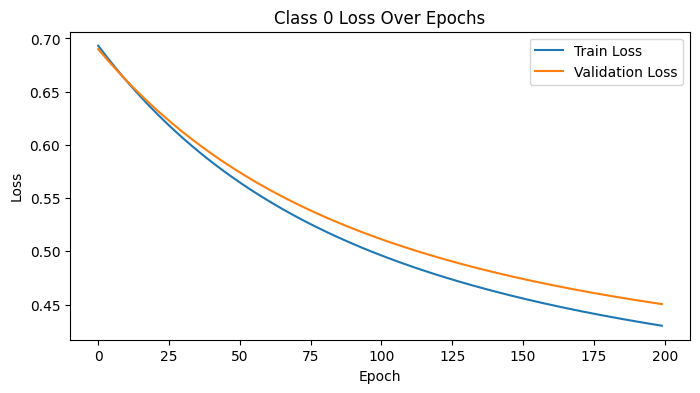

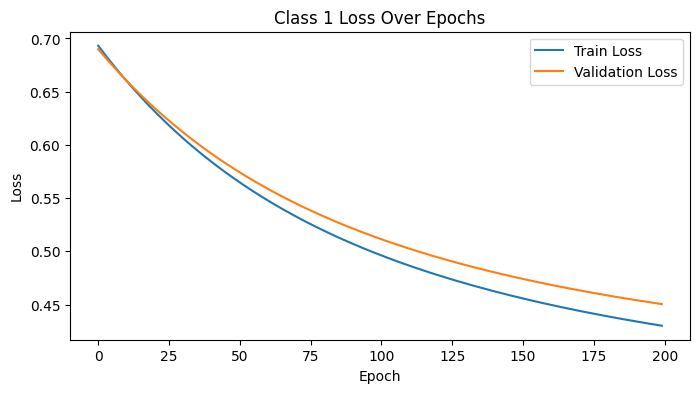

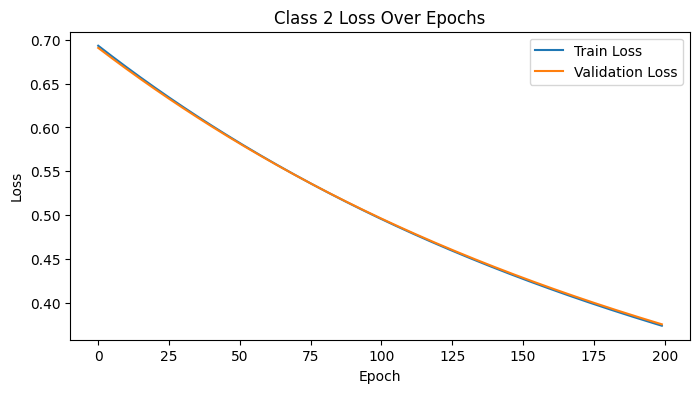

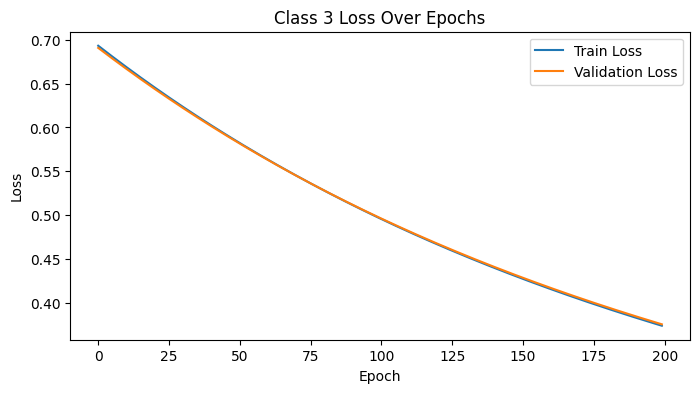

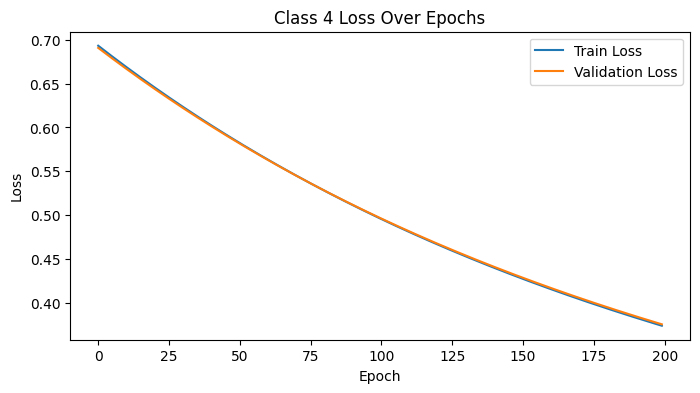

In [11]:
import matplotlib.pyplot as plt

# Plot training and validation loss for each class
for class_idx in range(n_classes):
    plt.figure(figsize=(8,4))
    plt.plot(ovr_model.train_loss_history[class_idx], label='Train Loss')
    plt.plot(ovr_model.val_loss_history[class_idx], label='Validation Loss')
    plt.title(f'Class {class_idx} Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


In [12]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Predict on Train, Validation, Test
y_train_pred = ovr_model.predict(X_train)
y_val_pred = ovr_model.predict(X_val)
y_test_pred = ovr_model.predict(X_test)

# Compute accuracies
acc_train = accuracy(y_train, y_train_pred)
acc_val = accuracy(y_val, y_val_pred)
acc_test = accuracy(y_test, y_test_pred)

print(f'Train Accuracy: {acc_train:.4f}')
print(f'Validation Accuracy: {acc_val:.4f}')
print(f'Test Accuracy: {acc_test:.4f}')


Train Accuracy: 0.8488
Validation Accuracy: 0.8333
Test Accuracy: 0.7864


## Explanation of Step 7

1. **Training**:
   - The `LogisticRegressionOVR` model was trained on the training data using Gradient Descent.
   - Validation loss was computed at each epoch to monitor the model's convergence.

2. **Loss Curves**:
   - Loss curves for each class show whether the model has stabilized or is still fluctuating.
   - The difference between Training and Validation Loss indicates whether the model is overfitting.

3. **Accuracy Evaluation**:
   - Training accuracy reflects the model's ability to learn from the seen samples.
   - Validation accuracy reflects the model's ability to generalize to unseen samples.
   - Test accuracy is used for final evaluation and official reporting.

4. **Insights**:
   - If Training Accuracy is very high but Validation/Test Accuracy is low → Overfitting.
   - If all three accuracies are roughly similar → The model generalizes well.
